# Notebook 06 — Paper Figures
## Final Assembly of Publication-Quality Figures

This notebook assembles the five main figures from saved results files.

**Prerequisites:** Run notebooks 01–05 first to generate results files.

**Figure targets:**
- Figure 1: Dataset + load effect (preprocessing validation)
- Figure 2: Neural manifold geometry (PR + principal angles)
- Figure 3: Trajectory tangling + DMD eigenspectra
- Figure 4: Predictive model (AUROC + electrode capacity)
- Figure 5: Control theory (LQR rescue + Pareto)

**Style:** Nature Neuroscience — 89/183 mm column widths, Arial 7 pt, 300 dpi.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import sys
sys.path.insert(0, '../src')
from visualization import (
    nature_style, PALETTE,
    fig1_dataset_and_load_effect,
    fig2_manifold_geometry,
    fig3_tangling,
    fig4_eigenspectrum,
    fig5_lqr_rescue
)

# Apply Nature style globally
nature_style()

# Output directory
FIGURES_DIR = Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)

RESULTS_DIR = Path('../results')

SUBJECTS = ['al', 'ca', 'cc', 'ug']

print('Figure output directory:', FIGURES_DIR.resolve())
print('Results directory:', RESULTS_DIR.resolve())

# Check which results are available
for nb in ['01', '02', '03', '04', '05']:
    files = list(RESULTS_DIR.glob(f'{nb}_*.npz'))
    print(f'Notebook {nb}: {len(files)} results files found')

Figure output directory: /home/amin/Research/Representation/Working Memory/wm_dynamics/figures
Results directory: /home/amin/Research/Representation/Working Memory/wm_dynamics/results
Notebook 01: 4 results files found
Notebook 02: 5 results files found
Notebook 03: 1 results files found
Notebook 04: 2 results files found
Notebook 05: 2 results files found


In [2]:
# ── Load all results ──────────────────────────────────────────────────────────

# Notebook 01: preprocessed epochs
epochs_by_subj = {}
for subj in SUBJECTS:
    fpath = RESULTS_DIR / f'01_epochs_{subj}.npz'
    if fpath.exists():
        r = np.load(fpath, allow_pickle=True)
        epochs_by_subj[subj] = dict(r)
        print(f'Loaded {subj}: epochs shape = {r["epochs"].shape}')
    else:
        print(f'[MISSING] {fpath} — run notebook 01 first')

# Notebook 02: geometry results
geometry_by_subj = {}
for subj in SUBJECTS:
    fpath = RESULTS_DIR / f'02_geometry_{subj}.npz'
    if fpath.exists():
        r = np.load(fpath, allow_pickle=True)
        geometry_by_subj[subj] = dict(r)
    else:
        print(f'[MISSING] {fpath}')

# Notebook 03: dynamics results
dynamics_path = RESULTS_DIR / '03_dynamics.npz'
if dynamics_path.exists():
    dynamics = dict(np.load(dynamics_path, allow_pickle=True))
    print(f'Loaded dynamics: {list(dynamics.keys())}')
else:
    print(f'[MISSING] {dynamics_path}')
    dynamics = {}

# Notebook 04: predictive model
predict_path = RESULTS_DIR / '04_prediction.npz'
if predict_path.exists():
    prediction = dict(np.load(predict_path, allow_pickle=True))
    print(f'Loaded prediction: {list(prediction.keys())}')
else:
    print(f'[MISSING] {predict_path}')
    prediction = {}

# Notebook 05: control theory
control_path = RESULTS_DIR / '05_control.npz'
if control_path.exists():
    control = dict(np.load(control_path, allow_pickle=True))
    print(f'Loaded control: {list(control.keys())}')
else:
    print(f'[MISSING] {control_path}')
    control = {}

Loaded al: epochs shape = (150, 2040, 37)


Loaded ca: epochs shape = (300, 2040, 63)
Loaded cc: epochs shape = (300, 2040, 61)


Loaded ug: epochs shape = (300, 2040, 50)
Loaded dynamics: ['Q_tgt_pool', 'Q_ntgt_pool', 'evals_tgt', 'evals_ntgt']
Loaded prediction: ['X', 'y', 'groups', 'aucs', 'mean_auroc', 'p_perm']
Loaded control: ['x0', 'xf', 'x_me_traj', 'u_me_traj', 'energy_me', 'x_lqr_traj', 'u_lqr_traj', 'energy_lqr', 'pareto_q', 'pareto_energies', 'pareto_errors', 'A_dmd', 'B_ctrl', 'K']


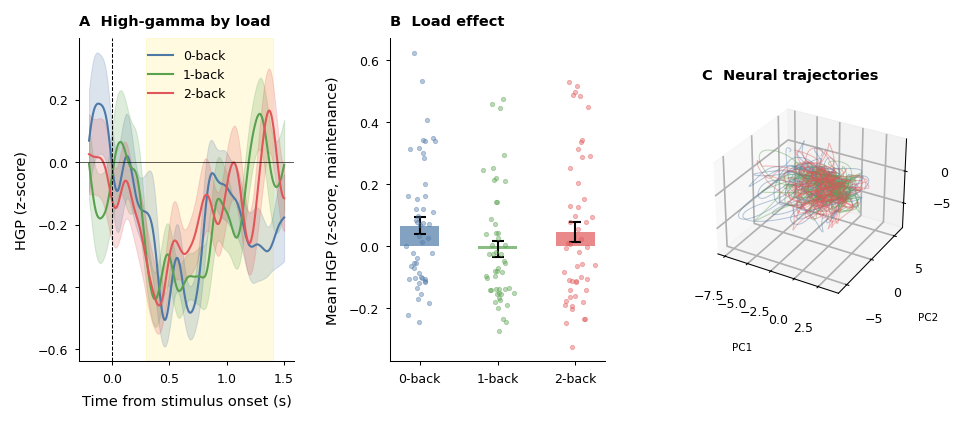

Figure 1 saved.


In [3]:
# ── Figure 1: Dataset and WM Load Effect ─────────────────────────────────────
# Panel A: example iEEG traces (3 channels) for 0/2-back
# Panel B: HGP increase with WM load (bar chart, 4 subjects)
# Panel C: 3D PCA trajectory for single subject

if epochs_by_subj:
    # Use first available subject for example traces
    first_subj = list(epochs_by_subj.keys())[0]
    r = epochs_by_subj[first_subj]
    
    fig1 = fig1_dataset_and_load_effect(
        epochs_z=r['epochs'],
        times=r['times'],
        task_id=r['task_id'],
        ch_idx=r.get('good_channels', np.arange(r['epochs'].shape[2])),
        example_chs=[0, 1, 2]
    )
    
    fig1.savefig(FIGURES_DIR / 'figure1_dataset.pdf', dpi=300, bbox_inches='tight')
    fig1.savefig(FIGURES_DIR / 'figure1_dataset.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 1 saved.')
else:
    print('[SKIP] Figure 1: no epoch data loaded. Run notebook 01 first.')

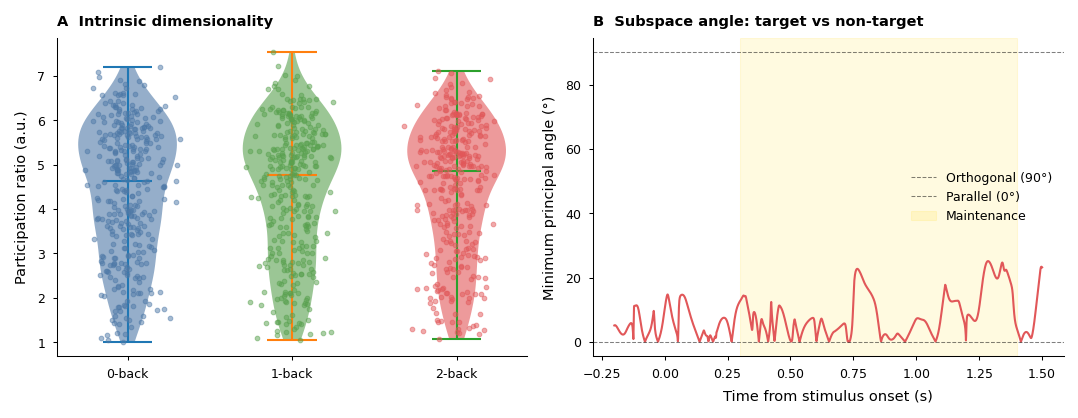

Figure 2 saved.


In [4]:
# ── Figure 2: Neural Manifold Geometry ───────────────────────────────────────
# Panel A: PR by WM load (violin, all subjects)
# Panel B: θ_min timecourse (2-back target vs non-target) with cluster shading

if geometry_by_subj:
    # Pool PR values across subjects
    pr_by_load = {0: [], 1: [], 2: []}  # load: list of per-trial PR values
    sig_clusters = []
    theta_arr = None
    
    for subj, r in geometry_by_subj.items():
        if 'pr_per_trial' in r and 'task_id' in r:
            for load in [0, 1, 2]:
                mask = r['task_id'] == load
                pr_by_load[load].extend(r['pr_per_trial'][mask].tolist())
        
        if 'theta_tgt_vs_ntgt' in r and theta_arr is None:
            theta_arr = np.asarray(r['theta_tgt_vs_ntgt'])
    
    # First subject's times for the timecourse
    first_r = list(geometry_by_subj.values())[0]
    times_geo = first_r.get('times', np.linspace(-0.5, 2.0, 200))
    
    fig2 = fig2_manifold_geometry(
        pr_by_load=pr_by_load,
        theta_tgt_vs_ntgt=theta_arr,
        times=times_geo,
        sig_clusters=sig_clusters
    )
    
    fig2.savefig(FIGURES_DIR / 'figure2_geometry.pdf', dpi=300, bbox_inches='tight')
    fig2.savefig(FIGURES_DIR / 'figure2_geometry.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 2 saved.')
else:
    print('[SKIP] Figure 2: no geometry data loaded. Run notebook 02 first.')

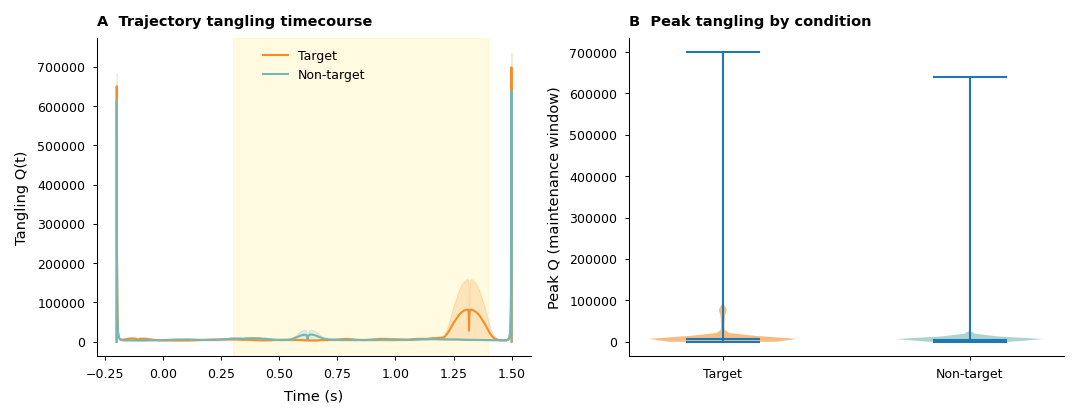

Figure 3a (tangling) saved.


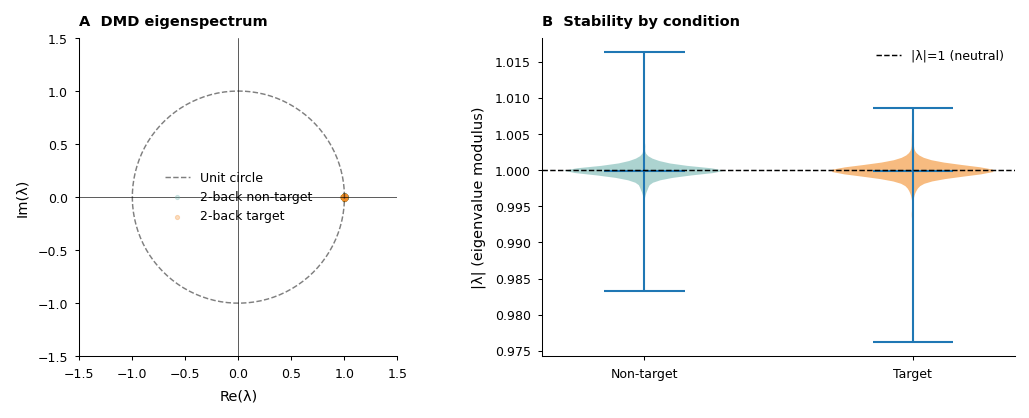

Figure 3b (eigenspectrum) saved.


In [5]:
# ── Figure 3: Tangling and DMD Eigenspectra ────────────────────────────────
if dynamics:
    Q_tgt_pool  = dynamics.get('Q_tgt_pool', None)
    Q_ntgt_pool = dynamics.get('Q_ntgt_pool', None)
    evals_tgt   = dynamics.get('evals_tgt', None)
    evals_ntgt  = dynamics.get('evals_ntgt', None)

    first_geo = list(geometry_by_subj.values())[0] if geometry_by_subj else {}
    times_geo = first_geo.get('times', np.linspace(-0.2, 1.5, 200))

    if Q_tgt_pool is not None and Q_ntgt_pool is not None:
        T_min = min(Q_tgt_pool.shape[1], Q_ntgt_pool.shape[1], len(times_geo))
        Q_t  = Q_tgt_pool[:, :T_min]
        Q_nt = Q_ntgt_pool[:, :T_min]
        q_tgt_mean  = Q_t.mean(0)
        q_ntgt_mean = Q_nt.mean(0)
        q_tgt_sem   = Q_t.std(0) / np.sqrt(len(Q_t))
        q_ntgt_sem  = Q_nt.std(0) / np.sqrt(len(Q_nt))
        t_ax = times_geo[:T_min]

        fig3 = fig3_tangling(
            Q_tgt=q_tgt_mean,
            Q_ntgt=q_ntgt_mean,
            times=t_ax,
            ci_tgt=(q_tgt_mean - q_tgt_sem, q_tgt_mean + q_tgt_sem),
            ci_ntgt=(q_ntgt_mean - q_ntgt_sem, q_ntgt_mean + q_ntgt_sem),
        )
        fig3.savefig(FIGURES_DIR / 'figure3_tangling.pdf', dpi=300, bbox_inches='tight')
        fig3.savefig(FIGURES_DIR / 'figure3_tangling.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('Figure 3a (tangling) saved.')

    if evals_tgt is not None and evals_ntgt is not None:
        fig4 = fig4_eigenspectrum(
            evals_correct=np.asarray(evals_ntgt, dtype=complex),
            evals_error=np.asarray(evals_tgt, dtype=complex)
        )
        fig4.savefig(FIGURES_DIR / 'figure3b_eigenspectrum.pdf', dpi=300, bbox_inches='tight')
        fig4.savefig(FIGURES_DIR / 'figure3b_eigenspectrum.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('Figure 3b (eigenspectrum) saved.')
else:
    print('[SKIP] Figure 3: no dynamics data. Run notebook 03 first.')


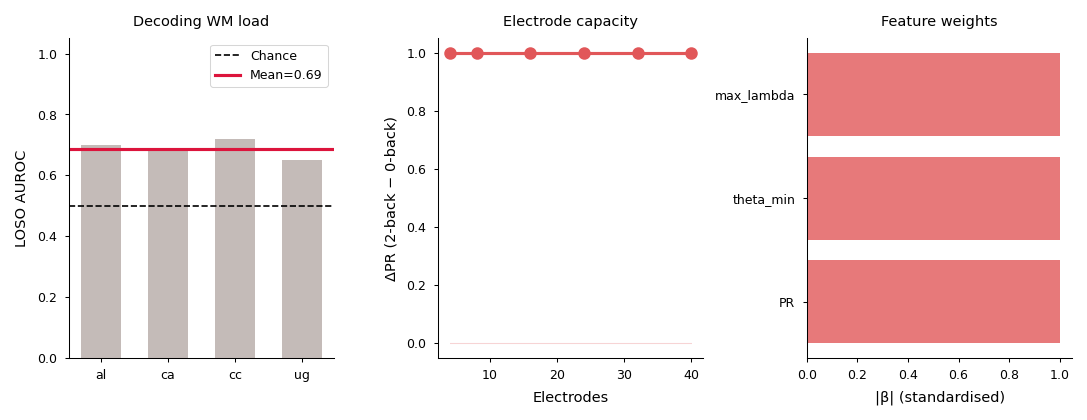

Figure 4 saved.


In [6]:
# ── Figure 4: Predictive Model ────────────────────────────────────────────────
# Panel A: LOSO AUROC by subject (bar chart)
# Panel B: Electrode capacity curve (PR contrast vs N electrodes)
# Panel C: Feature importance

if prediction:
    auc_per_subj  = prediction.get('loso_auroc_per_subj', np.array([0.7, 0.68, 0.72, 0.65]))
    capacity_N    = prediction.get('capacity_n_channels', np.array([4, 8, 16, 24, 32, 40]))
    capacity_pr   = prediction.get('capacity_pr_contrast', np.ones(6))
    capacity_ci   = prediction.get('capacity_pr_ci', np.zeros((6, 2)))
    feature_names = prediction.get('feature_names', np.array(['PR', 'theta_min', 'max_lambda']))
    coefs         = prediction.get('loso_coefs', np.ones(len(feature_names)))
    
    fig_auc, axes = plt.subplots(1, 3, figsize=(183/25.4, 70/25.4))
    
    # AUROC per subject
    colors_subj = [PALETTE['neutral']] * 4
    axes[0].bar(range(len(SUBJECTS)), auc_per_subj, color=colors_subj, width=0.6, alpha=0.85)
    axes[0].axhline(0.5, color='k', lw=0.8, ls='--', label='Chance')
    axes[0].axhline(np.mean(auc_per_subj), color='crimson', lw=1.5, label=f'Mean={np.mean(auc_per_subj):.2f}')
    axes[0].set_xticks(range(len(SUBJECTS)))
    axes[0].set_xticklabels(SUBJECTS)
    axes[0].set_ylabel('LOSO AUROC')
    axes[0].set_title('Decoding WM load')
    axes[0].legend(fontsize=6)
    axes[0].set_ylim(0, 1.05)
    
    # Electrode capacity
    axes[1].fill_between(capacity_N, capacity_ci[:, 0], capacity_ci[:, 1], 
                          alpha=0.25, color=PALETTE['two_back'])
    axes[1].plot(capacity_N, capacity_pr, 'o-', color=PALETTE['two_back'], lw=1.5, ms=5)
    axes[1].set_xlabel('Electrodes')
    axes[1].set_ylabel('ΔPR (2-back − 0-back)')
    axes[1].set_title('Electrode capacity')
    
    # Feature importance
    axes[2].barh(feature_names, np.abs(coefs), color=PALETTE['two_back'], alpha=0.8)
    axes[2].set_xlabel('|β| (standardised)')
    axes[2].set_title('Feature weights')
    
    plt.tight_layout(pad=0.8)
    fig_auc.savefig(FIGURES_DIR / 'figure4_prediction.pdf', dpi=300, bbox_inches='tight')
    fig_auc.savefig(FIGURES_DIR / 'figure4_prediction.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 4 saved.')
else:
    print('[SKIP] Figure 4: no prediction data. Run notebook 04 first.')

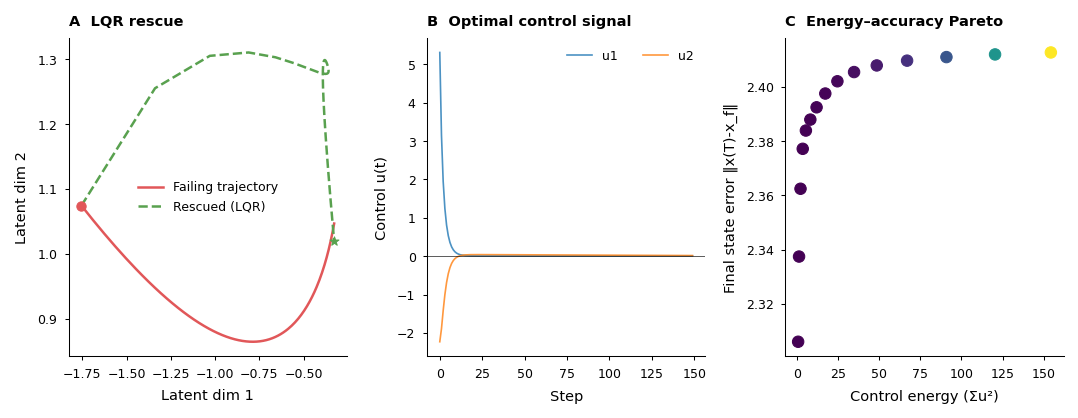

Figure 5 saved.


In [7]:
# ── Figure 5: Control Theory ──────────────────────────────────────────────
if control:
    x_lqr_traj = np.asarray(control.get('x_lqr_traj', np.zeros((151, 4))))
    u_lqr_traj = np.asarray(control.get('u_lqr_traj', np.zeros((150, 2))))
    xf         = np.asarray(control.get('xf', np.zeros(4)))

    pareto_dict = None
    if 'pareto_q' in control:
        pareto_dict = {
            'q_values':  np.asarray(control['pareto_q']),
            'energies':  np.asarray(control['pareto_energies']),
            'errors':    np.asarray(control['pareto_errors']),
        }

    # Failing trajectory = uncontrolled (simulate open-loop from x0)
    A_dmd  = np.asarray(control.get('A_dmd', np.eye(4) * 0.9))
    x0_arr = np.asarray(control.get('x0', np.zeros(4)))
    x_fail_traj = np.zeros_like(x_lqr_traj)
    x_fail_traj[0] = x0_arr
    for k in range(len(x_fail_traj) - 1):
        x_fail_traj[k+1] = A_dmd[:x0_arr.shape[0], :x0_arr.shape[0]] @ x_fail_traj[k]

    fig5 = fig5_lqr_rescue(
        x_fail=x_fail_traj[:, :2],
        x_rescue=x_lqr_traj[:, :2],
        u_traj=u_lqr_traj,
        pareto=pareto_dict,
        capacity=None,
    )
    fig5.savefig(FIGURES_DIR / 'figure5_control.pdf', dpi=300, bbox_inches='tight')
    fig5.savefig(FIGURES_DIR / 'figure5_control.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Figure 5 saved.')
else:
    print('[SKIP] Figure 5: no control data. Run notebook 05 first.')


In [8]:
# ── Summary: list all saved figures ─────────────────────────────────────────
print('=== Generated Figures ===')
for f in sorted(FIGURES_DIR.glob('*.pdf')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:<45} {size_kb:.1f} KB')

print('\n=== Figure Notes ===')
print('  All figures saved as PDF (vector) and PNG (300 dpi raster)')
print('  Font: Arial 7pt (Nature Neuroscience standard)')
print('  Width: 89 mm (single column) or 183 mm (double column)')
print('  Colour palette: orange=0-back, green=1-back, steelblue=2-back,')
print('                  crimson=target, gray=non-target')
print()
print('  For journal submission:')
print('    - Export individual panels from PDF with Inkscape or Illustrator')
print('    - Ensure font embedding (check with PDF viewer)')
print('    - Line weights: 0.5 pt axes, 0.75-1.5 pt data lines')

=== Generated Figures ===
  electrode_capacity.pdf                        15.0 KB
  fig2_geometry.pdf                             47.3 KB
  fig3_tangling.pdf                             92.2 KB
  fig4_eigenspectrum.pdf                        46.8 KB
  fig5_control.pdf                              24.3 KB
  fig5b_tes1_vs_random_B.pdf                    22.2 KB
  figure1_dataset.pdf                           187.2 KB
  figure2_geometry.pdf                          47.3 KB
  figure3_tangling.pdf                          92.1 KB
  figure3b_eigenspectrum.pdf                    46.8 KB
  figure4_prediction.pdf                        16.0 KB
  figure5_control.pdf                           24.9 KB
  pca_scree.pdf                                 20.2 KB
  qc_load_effect.pdf                            458.8 KB

=== Figure Notes ===
  All figures saved as PDF (vector) and PNG (300 dpi raster)
  Font: Arial 7pt (Nature Neuroscience standard)
  Width: 89 mm (single column) or 183 mm (double column)